# Model 0 & Model 1: Baseline models

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

In [3]:
import pandas as pd
import numpy as np

from src.features import add_all_features
from src.evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

### Load data, drop nulls, generate features

In [4]:
raw_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_question_pairs_train_.csv', index_col=0)

In [5]:
raw_df = raw_df.dropna(subset=['question1', 'question2']).copy()

In [6]:
add_all_features(raw_df, q1_col="question1", q2_col="question2")

,qid1,qid2,question1,question2,is_duplicate,question1_len,question2_len,len_dif,common_words,jaccard_similarity,word_match_share,bigrams_common,bigram_jaccard_similarity,bigram_word_match_share,cosine_similarity
id,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,47,81,-34,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,62,55,7,3.0,0.600000,0.375000,1.0,0.200000,0.166667,0.827243
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,32,78,-46,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.149953
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,51,42,9,2.0,0.250000,0.200000,1.0,0.142857,0.125000,0.345153
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,159,68,91,4.0,0.235294,0.190476,1.0,0.055556,0.052632,0.233961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,90,89,1,5.0,0.714286,0.416667,3.0,0.428571,0.300000,0.736964
90934,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,84,86,-2,1.0,0.111111,0.100000,0.0,0.000000,0.000000,0.415535
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0,45,49,-4,1.0,0.142857,0.125000,0.0,0.000000,0.000000,0.569104


### Train/validation split

In [7]:
# deviding of train daset on train and val
X = raw_df.drop(columns=['is_duplicate'])
y = raw_df['is_duplicate']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

#### Model 0: majority class baseline

In [8]:
majority_class = y_train.value_counts().idxmax()
y_pred_majority = np.full(len(y_val), majority_class)
y_prob_majority = np.full(len(y_val), y_train.mean())

In [9]:

results_model_0 = compute_metrics(y_val, y_pred_majority, y_prob_majority, 'Model 0: Majority class baseline', threshold=None)

model: Model 0: Majority class baseline

threshold: None

params: None

train_time_sec: None

train_f1: None

train_roc_auc: None

train_log_loss: None

f1: 0.0

roc_auc: 0.5

log_loss: 0.6585279444319896



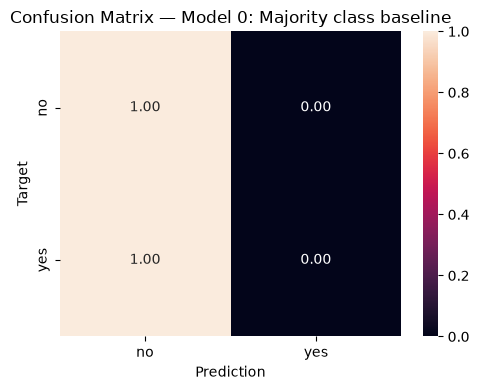

In [10]:
plot_confusion_matrix(y_val, y_pred_majority, 'Model 0: Majority class baseline')


In [11]:
append_to_experiment_table(results_model_0, path='/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/reports/experiment_table.csv')

#### Model 1: cosine similarity

In [12]:
#chosing of threshold

best_f1, best_threshold = 0, 0
for threshold in np.arange(0.1, 0.9, 0.05):
    y_pred_temp = (X_train['cosine_similarity'] > threshold).astype(int)
    f1 = f1_score(y_train, y_pred_temp)
    if f1 > best_f1:
        best_f1, best_threshold = f1, threshold

#prediction on val
y_pred = (X_val['cosine_similarity'] > best_threshold).astype(int)

In [13]:
#metrics calculation

results_model_1 = compute_metrics(y_val, y_pred, X_val['cosine_similarity'], 'Model 1: cosine similarity', threshold=best_threshold)


model: Model 1: cosine similarity

threshold: 0.3500000000000001

params: None

train_time_sec: None

train_f1: None

train_roc_auc: None

train_log_loss: None

f1: 0.63113377147741

roc_auc: 0.73442959225784

log_loss: 1.1061281457092904



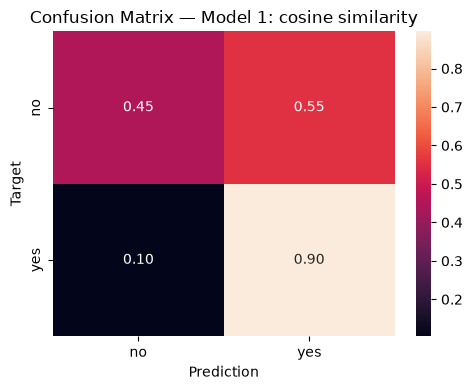

In [14]:
plot_confusion_matrix(y_val, y_pred, 'Model 1: cosine similarity')



In [15]:
append_to_experiment_table(results_model_1, path='/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/reports/experiment_table.csv')